# Q-learning: glucose, actions, and transfer

Reusable code (episode logging, training/evaluation, plots) lives in `analysis.py`; this notebook only sets parameters, runs experiments, and shows results.

**How to run:** run the **Setup** cells, then any section on its own. Sections don't depend on each other.
1. **Single agent**: train one agent in `ENV_PARAMS`, inspect learning and individual episodes
2. **Transfer**: train a sparse-food and an abundant-food agent, freeze both, evaluate each in both environments

Edits to `analysis.py`, `GridWorld.py`, or `QLearningAgent.py` are picked up automatically (`%autoreload 2`); just rerun the experiment cell.

## Setup

In [22]:
%load_ext autoreload
%autoreload 2

# allows to import modules from root directory
import sys
import os
sys.path.append(os.path.abspath('..'))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
import numpy as np
import matplotlib.pyplot as plt

from GridWorld import GridWorld, Action
from QLearningAgent import QLearningAgent
from analysis import (
    run_episode, action_counts, describe_episode,
    train_agent, evaluate, summarize, print_summary_table,
    plot_episode_lengths, plot_action_mix, plot_trajectories, episode_title, plot_episode_maps,
    plot_condition_outcomes, plot_mean_glucose,
)

Shared parameters. Each section builds its own environments and agents from these dicts, and sets its own section-specific knobs at the top of the section.

In [24]:
SEED = None
PLOT_DIR = "../plots"

ENV_PARAMS = dict(grid_size=8, glucose_target=50, glucose_max=100,
                  n_food=5, max_steps=200, metabolism_rate=1, intake_amount=10,
                  drive_n=2, drive_m=1)
AGENT_PARAMS = dict(alpha=0.3, gamma=0.95,
                    epsilon_start=1.0, epsilon_min=0.05, epsilon_decay=0.9)
N_EPISODES = 5000 # training episodes per agent

## 1. Single agent
Train one agent in `ENV_PARAMS`, keeping per-episode summaries for every episode and full step-by-step trajectories for `RECORD_EPISODES`.

Each step is put into one of three action categories:
- **move**: UP / DOWN / LEFT / RIGHT
- **eat**: EAT (only allowed on a food tile, so it always consumes food)
- **idle**: IDLE

The environment masks actions: `obs["valid_actions"]` lists what's allowed from the current tile, and the agent only chooses (and bootstraps its Q-update) from those.

In [25]:
RECORD_EPISODES = [0, 10, 100, 1000, N_EPISODES - 1] # episodes whose full trajectory we keep
WINDOW = 100 # moving-average window for the training curves

agent, history = train_agent(ENV_PARAMS, AGENT_PARAMS, N_EPISODES, seed=SEED,
                             record_episodes=RECORD_EPISODES)
trajectories = history["trajectories"]
for ep, traj in trajectories.items():
    print(describe_episode(f"episode {ep:>5}", traj))

episode     0: 60 steps, total reward -2500.0, eps=1.000, ate 1/5, idle 11, move 48  (Agent starved to death.)
episode    10: 60 steps, total reward -2500.0, eps=0.349, ate 1/5, idle 11, move 48  (Agent starved to death.)
episode   100: 100 steps, total reward -2500.0, eps=0.050, ate 5/5, idle 17, move 78  (Agent starved to death.)
episode  1000: 100 steps, total reward -2500.0, eps=0.050, ate 5/5, idle 23, move 72  (Agent starved to death.)
episode  4999: 100 steps, total reward -2500.0, eps=0.050, ate 5/5, idle 5, move 90  (Agent starved to death.)


### Greedy rollout of the learned policy
Run one episode with epsilon = 0 and no Q-table updates, to see what the learned policy does on its own.

In [26]:
greedy_traj = evaluate(agent, ENV_PARAMS, n_episodes=1)[0]
print(describe_episode("greedy", greedy_traj))

greedy: 100 steps, total reward -2500.0, eps=0.000, ate 5/5, idle 9, move 86  (Agent starved to death.)


### Learning curve
Episode length (steps survived) per episode (light) and a moving average (dark); dotted lines mark the recorded episodes.

Note: total reward per episode is not a useful learning signal here. Since reward = drive(t) - drive(t+1), the per-episode sum telescopes to drive(start) - drive(end), so every episode that ends in starvation gets the same total.

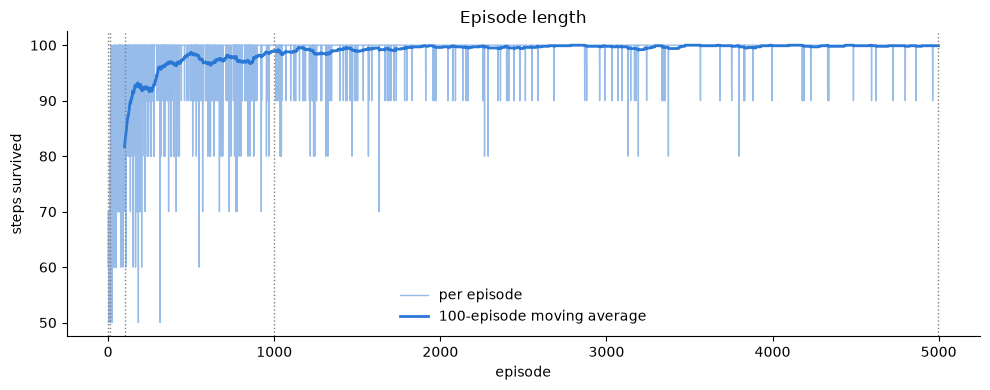

In [27]:
plot_episode_lengths(history, WINDOW, mark_episodes=RECORD_EPISODES,
                     fname=f"{PLOT_DIR}/episode_lengths.png")

### Glucose and reward over representative episodes
One column per episode. Rows: glucose (dashed line = target; orange ticks = EATs), action strip (EAT and IDLE), food remaining, per-step reward, cumulative reward. Rows share a y-axis so episodes are directly comparable.

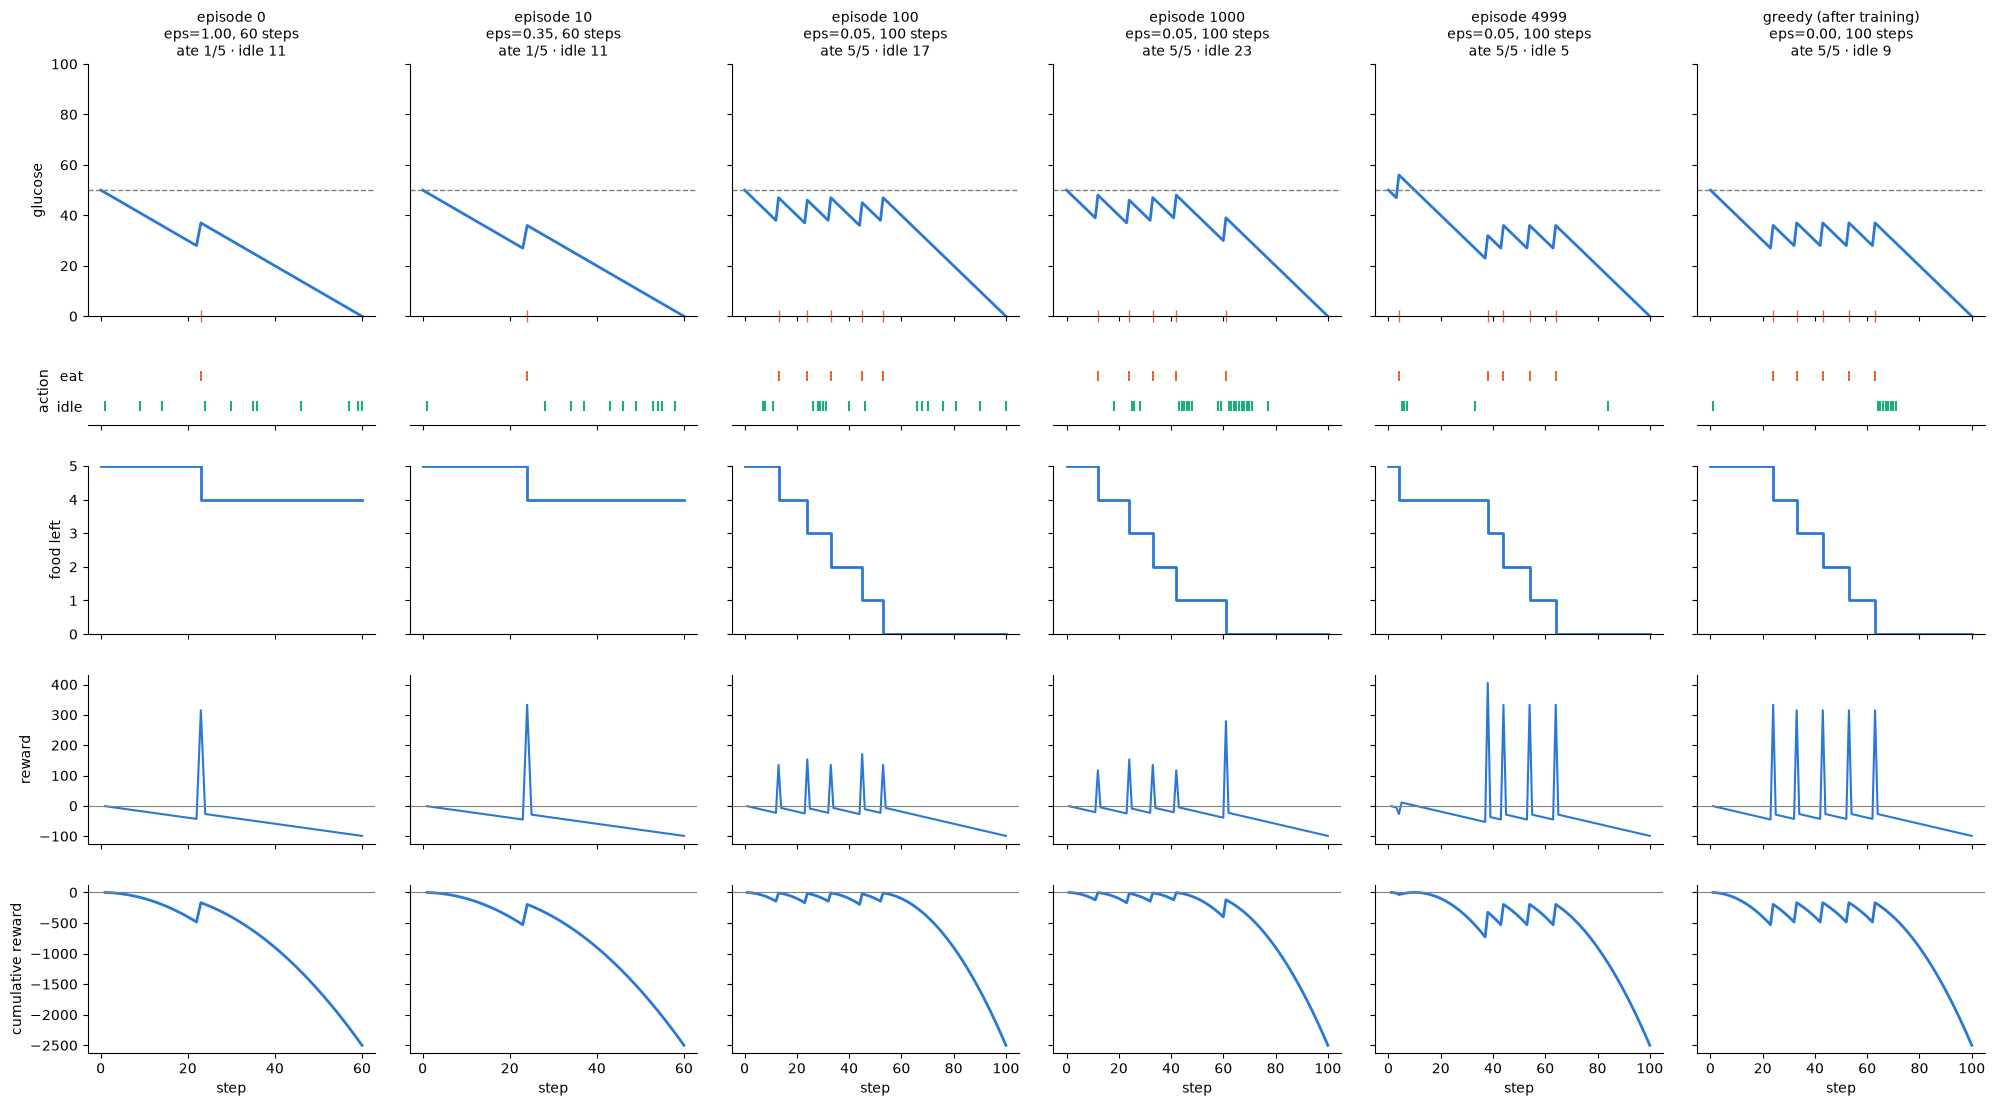

In [28]:
plot_trajs = {f"episode {ep}": trajectories[ep] for ep in RECORD_EPISODES}
plot_trajs["greedy (after training)"] = greedy_traj
titles = [episode_title(k, v) for k, v in plot_trajs.items()]
plot_trajectories(plot_trajs, ENV_PARAMS, titles=titles, fname=f"{PLOT_DIR}/trajectories.png")

### Episode maps: food and navigation
One panel per episode. Squares are the food placed at the start of the episode: **filled** = eaten (fill color = step it was eaten, on the same scale as the path), **hollow gray** = left over. The path is colored by step (light = early, dark = late); dots mark steps where the agent didn't move (IDLE, EAT, or walking into a wall). Each step is jittered slightly so repeated moves along the same edge don't hide each other.

`mode="heatmap"` replaces the path with how many steps the agent spent on each tile, which is easier to read for long episodes.

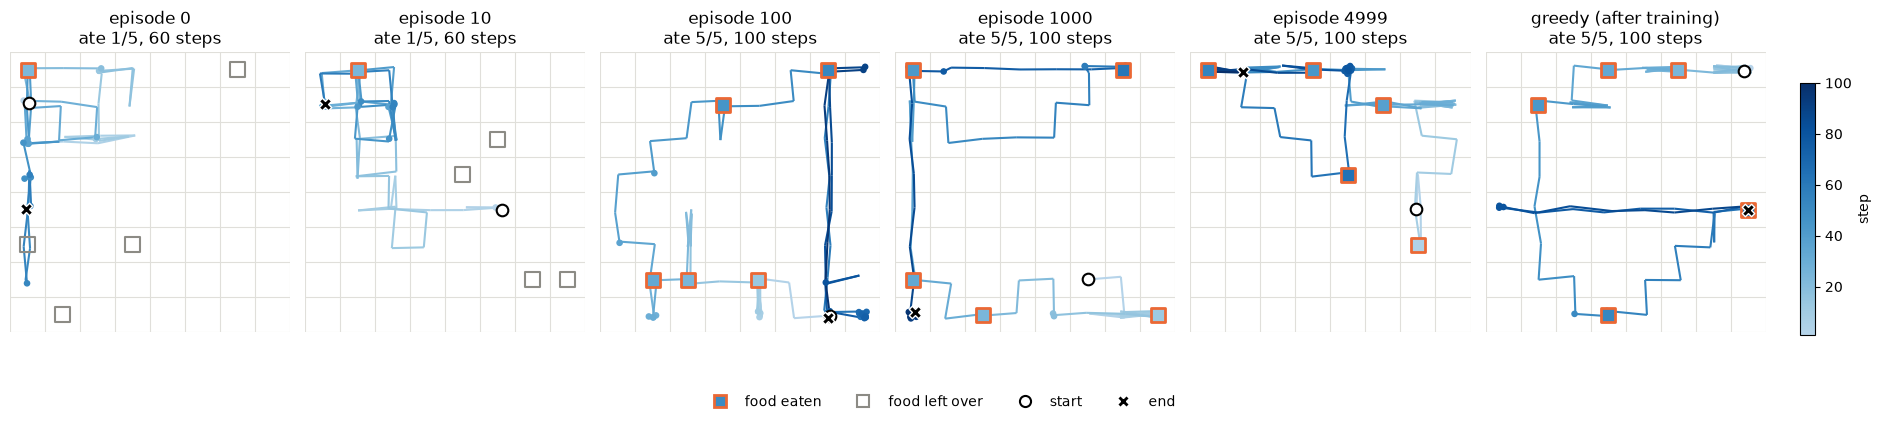

In [29]:
plot_episode_maps(plot_trajs, ENV_PARAMS, fname=f"{PLOT_DIR}/episode_maps.png")

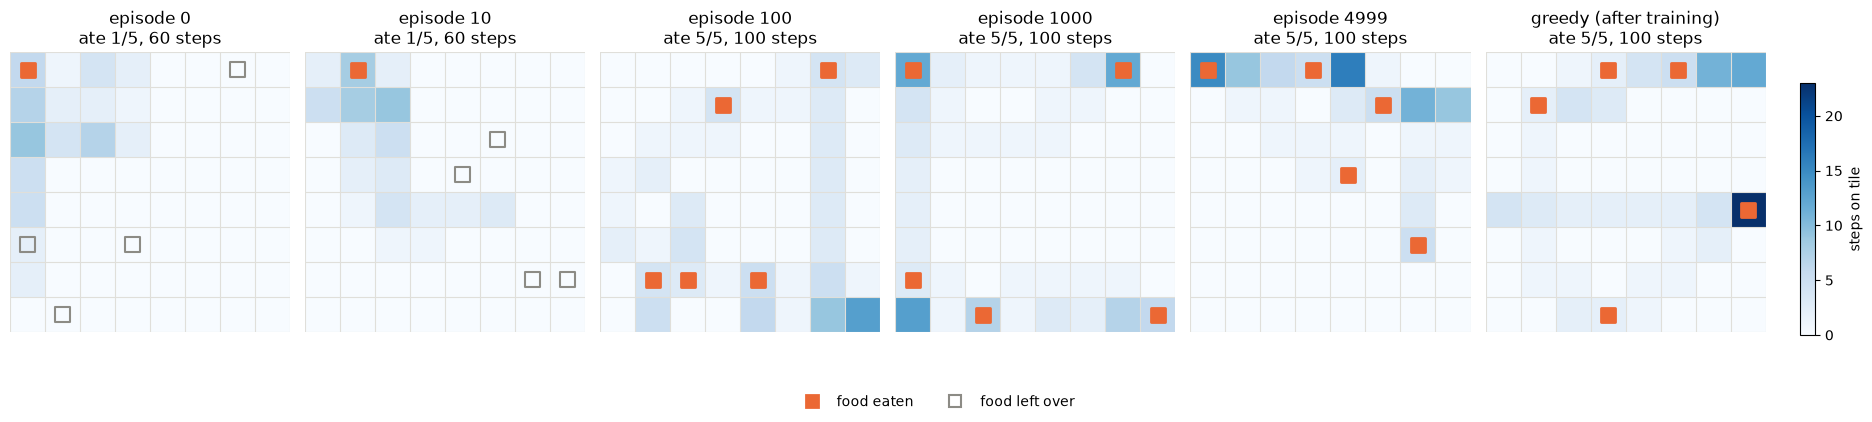

In [30]:
plot_episode_maps(plot_trajs, ENV_PARAMS, mode="heatmap", fname=f"{PLOT_DIR}/episode_visit_heatmaps.png")

### Action mix and food left over across training
Left: for every episode we compute the share of its steps in each action category (shares, not counts, so episodes of different lengths are comparable). Single-episode shares are noisy (episodes are short, so one extra IDLE moves a share by several points), so the plotted line is the **mean share over a sliding window of the previous `WINDOW` episodes**. The first full window ends at episode `WINDOW - 1`, which is why the lines start there instead of at 0. Right: food left when the episode ends. Dotted lines mark the recorded episodes.

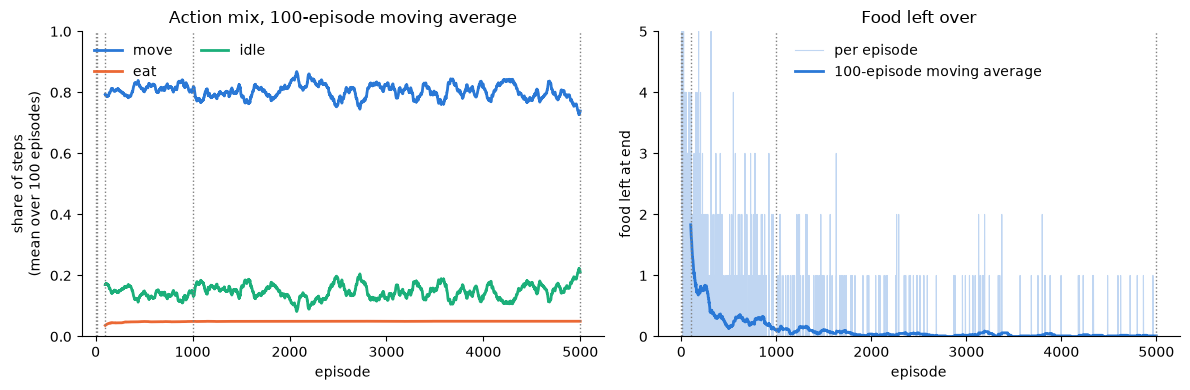

In [31]:
plot_action_mix(history, ENV_PARAMS["n_food"], WINDOW, mark_episodes=RECORD_EPISODES,
                fname=f"{PLOT_DIR}/action_mix_food_left.png")

## 2. Transfer: sparse-trained agent in an abundant environment
Train two agents, one in a sparse-food environment and one in an abundant-food environment (same hyperparameters, same number of episodes; otherwise identical environments). Then **freeze** both (epsilon = 0, no Q-table updates) and evaluate each in both environments. This section trains its own agents and doesn't use section 1.

Each of the 4 conditions runs `N_EVAL` episodes. Evaluation environments are seeded, so within one environment both agents face the same sequence of food layouts and start positions.

The Q-table is keyed on (distance to nearest food, direction, glucose bin), none of which depend on how much food there is, so it carries over as is. The agent can still reach states it never trained on, though. Their Q-values are all 0, so the frozen agent picks a random allowed action there.

In [32]:
SPARSE_N_FOOD = 5
ABUNDANT_N_FOOD = 20
N_EVAL = 200 # evaluation episodes per condition
EVAL_SEED = 12345 # same layouts for both agents within an environment
AGENT_COLORS = {"sparse-trained": "#2a78d6", "abundant-trained": "#eb6834"}

EVAL_ENV_PARAMS = {
    "sparse": {**ENV_PARAMS, "n_food": SPARSE_N_FOOD},
    "abundant": {**ENV_PARAMS, "n_food": ABUNDANT_N_FOOD},
}

sparse_agent, _ = train_agent(EVAL_ENV_PARAMS["sparse"], AGENT_PARAMS, N_EPISODES, seed=SEED)
abundant_agent, _ = train_agent(EVAL_ENV_PARAMS["abundant"], AGENT_PARAMS, N_EPISODES, seed=SEED)
TRANSFER_AGENTS = {"sparse-trained": sparse_agent, "abundant-trained": abundant_agent}

### Summary table
Means over the `N_EVAL` frozen episodes of each condition.
- **survived**: share of episodes that reached `max_steps` without starving
- **share eaten**: food eaten / food available
- **steps above target**: share of steps ending with glucose above the target
- **eats above target**: share of EATs taken with glucose already at or above the target
- **unseen**: share of steps taken from states without trained Q-values

In [33]:
evals = {} # (agent label, env label) -> list of trajectories
summaries = {}
for a_label, a in TRANSFER_AGENTS.items():
    for e_label, params in EVAL_ENV_PARAMS.items():
        evals[(a_label, e_label)] = evaluate(a, params, n_episodes=N_EVAL, seed=EVAL_SEED)
        summaries[(a_label, e_label)] = summarize(evals[(a_label, e_label)], a, params)

print_summary_table(summaries)

agent             eval env                 steps            survived          food eaten         share eaten  steps above target   eats above target              unseen
sparse-trained    sparse                   99.55                0.00                4.96                0.99                0.00                0.00                0.00
sparse-trained    abundant                200.00                1.00               17.99                0.90                0.00                0.00                0.00
abundant-trained  sparse                   99.90                0.00                4.99                1.00                0.30                0.00                0.48
abundant-trained  abundant                200.00                1.00               19.91                1.00                0.73                0.00                0.00


### Per-episode outcomes
Each box is the distribution over the `N_EVAL` frozen episodes of one condition, grouped by evaluation environment and colored by the environment the agent was trained in. Right panel: mean distance from the glucose target over each episode (lower = closer to homeostasis).

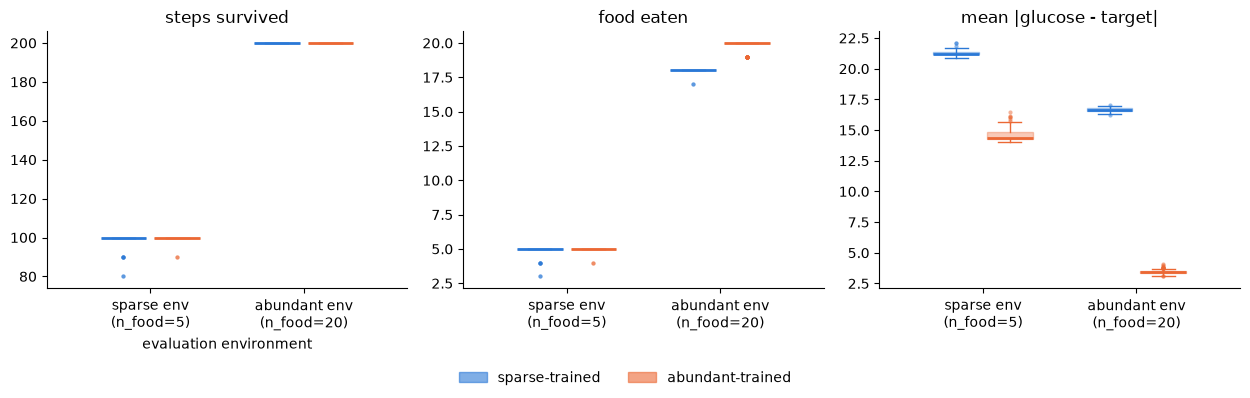

In [34]:
plot_condition_outcomes(evals, EVAL_ENV_PARAMS, AGENT_COLORS, fname=f"{PLOT_DIR}/transfer_outcomes.png")

### Glucose over the episode
Mean glucose at each step across the frozen episodes still running at that step, one panel per evaluation environment. Lines stop once fewer than 10% of episodes are still running. Dashed line = target. A sparse-trained agent that never got above the target in training may overshoot it in the abundant environment.

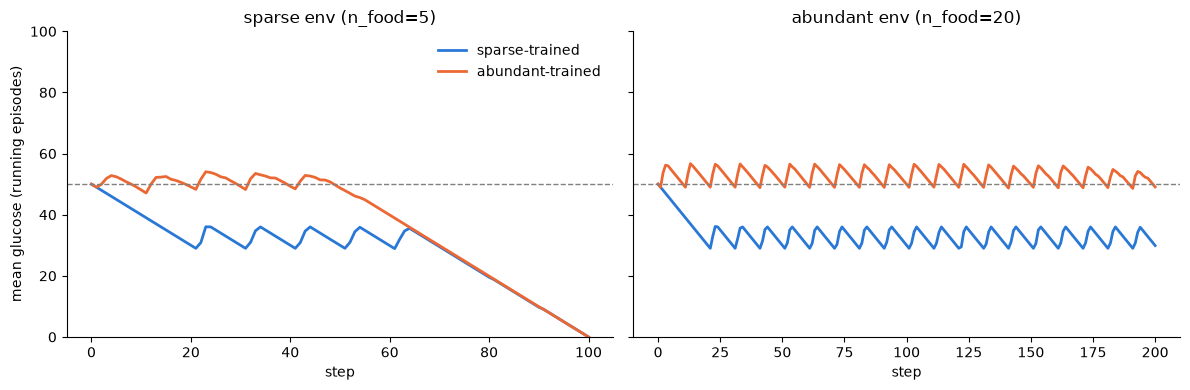

In [35]:
plot_mean_glucose(evals, EVAL_ENV_PARAMS, AGENT_COLORS, min_running=0.1,
                  fname=f"{PLOT_DIR}/transfer_glucose.png")

### Example frozen episodes
The first evaluation episode of each condition. Within an environment both agents got the same food layout and start position (seeded evaluation env), so columns 1 & 3 and 2 & 4 are directly comparable.

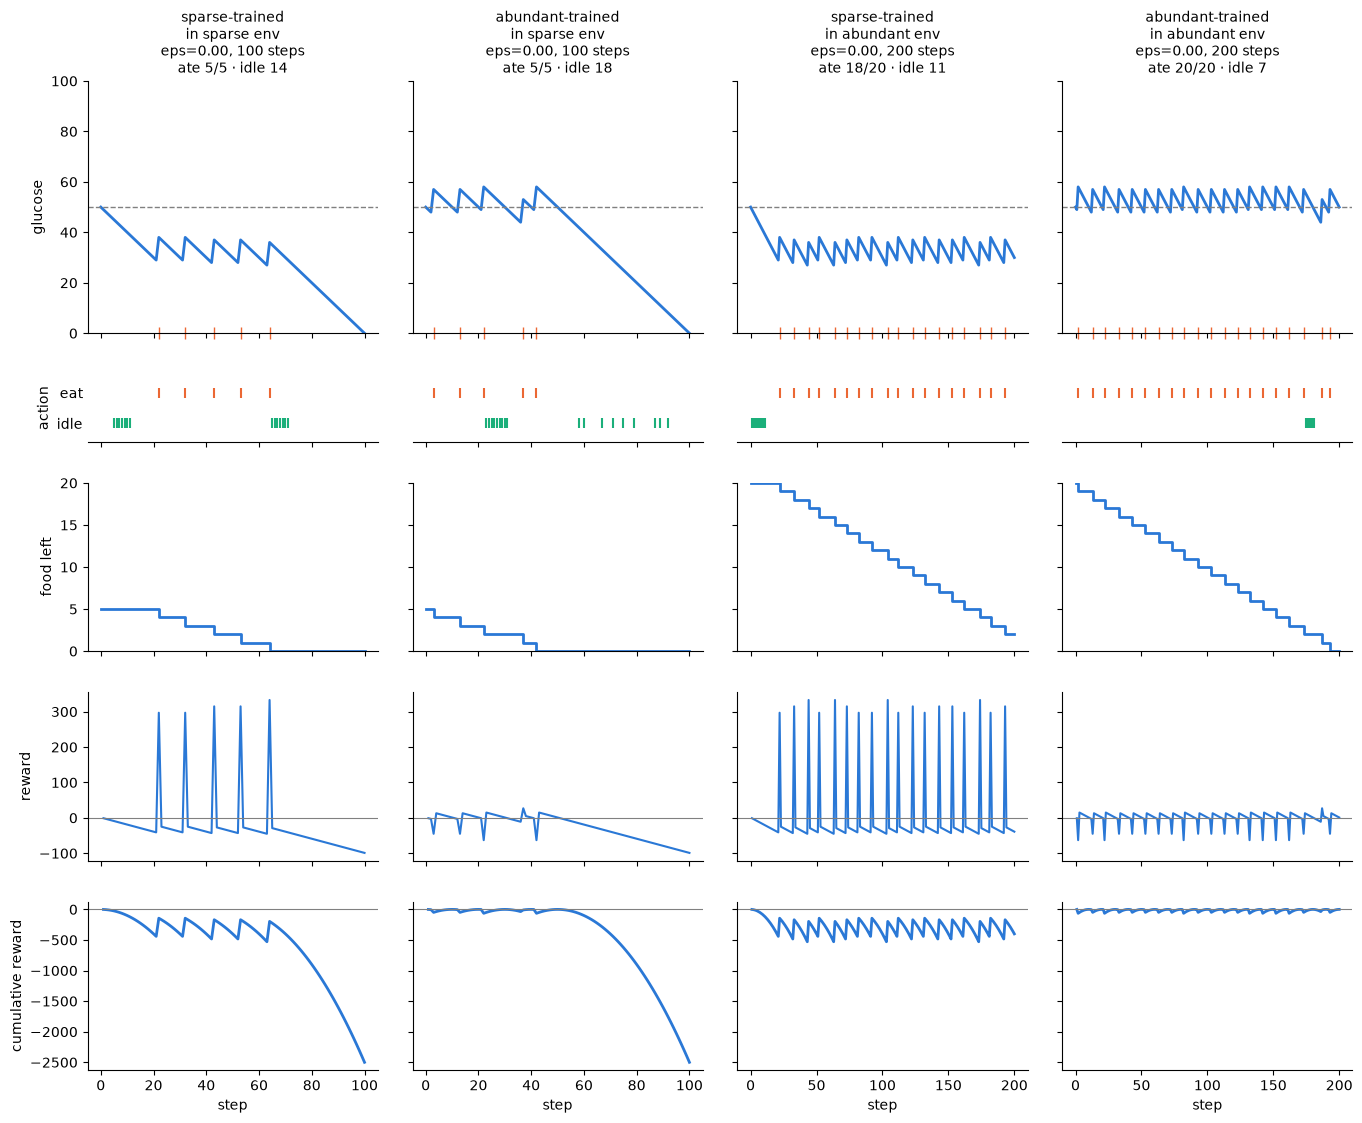

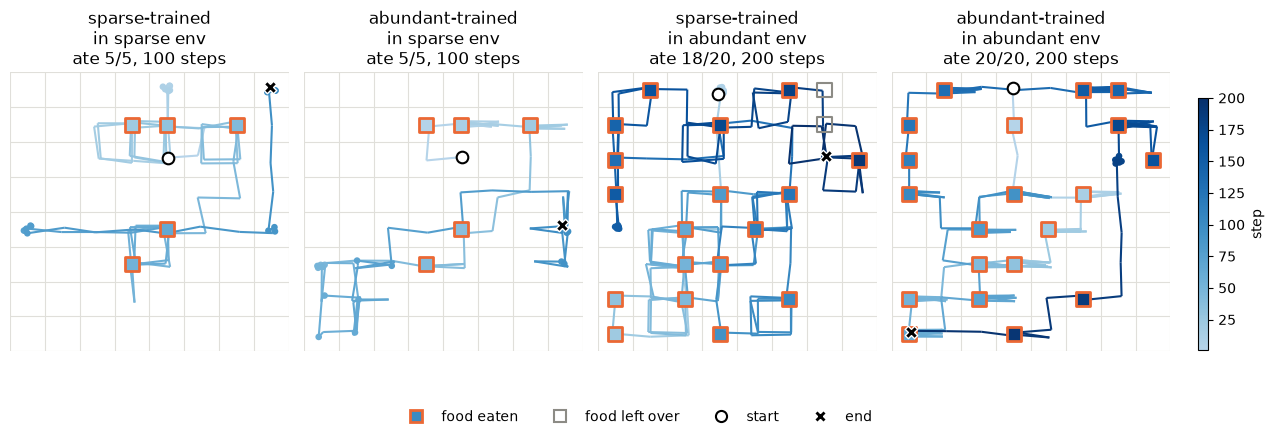

In [36]:
example_trajs = {}
for e_label in EVAL_ENV_PARAMS:
    for a_label in TRANSFER_AGENTS:
        example_trajs[f"{a_label}\nin {e_label} env"] = evals[(a_label, e_label)][0]

# axis limits come from the abundant env's parameters, which cover both environments' food counts
plot_trajectories(example_trajs, EVAL_ENV_PARAMS["abundant"],
                  titles=[episode_title(k, v) for k, v in example_trajs.items()],
                  fname=f"{PLOT_DIR}/transfer_trajectories.png")
plot_episode_maps(example_trajs, EVAL_ENV_PARAMS["abundant"], fname=f"{PLOT_DIR}/transfer_episode_maps.png")